In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Load the Wisconsin Diagnostic Breast Cancer Dataset

Load the dataset and separate the input features and target variable for classification.

In [3]:
# Column names from the WDBC dataset
columns = [
    "ID",
    "Diagnosis",

    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",

    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",

    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]

# Load the dataset
df = pd.read_csv(
    "Downloads/breast+cancer+wisconsin+diagnostic/wdbc.data",
    header=None,
    names=columns
)

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (569, 32)


,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Separate Features and Target

Separate the patient ID, input features, and diagnosis target. The ID column is removed because it does not provide useful predictive information.

In [4]:
# Remove ID because it is only an identifier
X = df.drop(columns=["ID", "Diagnosis"])

# Target variable
y = df["Diagnosis"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nTarget Classes:")
print(y.value_counts())

X Shape: (569, 30)
y Shape: (569,)

Target Classes:
Diagnosis
B    357
M    212
Name: count, dtype: int64


# Encode Target Variable

Convert the categorical diagnosis labels into numerical values for machine learning. Malignant is represented by 0 and Benign by 1.

In [5]:
y = y.map({
    "M": 0,
    "B": 1
})

print("Encoded Target Classes:")
print(y.value_counts())

print("\nUnique Target Values:")
print(y.unique())

Encoded Target Classes:
Diagnosis
1    357
0    212
Name: count, dtype: int64

Unique Target Values:
[0 1]


# Dataset Inspection

Check the data types, missing values, duplicate rows, and basic statistical information before training the models.

In [7]:
print("Dataset Information:")
X.info()

print("\nTotal Missing Values:")
print(X.isnull().sum().sum())

print("\nTotal Duplicate Rows:")
print(X.duplicated().sum())

print("\nStatistical Summary:")
display(X.describe().T)

print("\nTarget Distribution:")
print(y.value_counts())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave_points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoothness_se   

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave_points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744



Target Distribution:
Diagnosis
1    357
0    212
Name: count, dtype: int64


# Exploratory Data Analysis – Class Distribution

Visualize the distribution of Malignant (M) and Benign (B) cases in the dataset.

Class Distribution:
Diagnosis
B    357
M    212
Name: count, dtype: int64


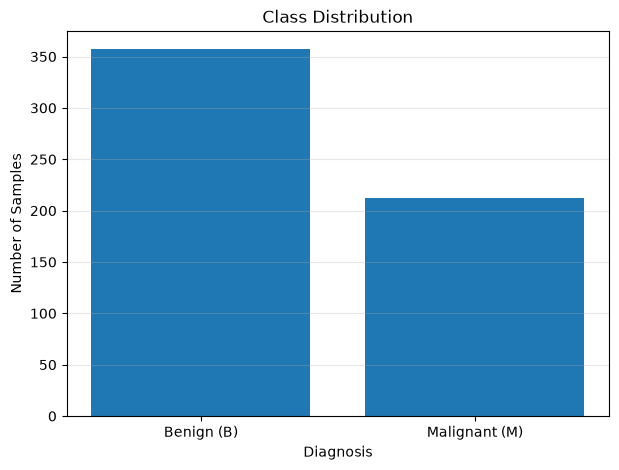

In [8]:

class_counts = df["Diagnosis"].value_counts()

print("Class Distribution:")
print(class_counts)

plt.figure(figsize=(7, 5))

plt.bar(
    ["Benign (B)", "Malignant (M)"],
    [
        class_counts.get("B", 0),
        class_counts.get("M", 0)
    ]
)

plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Observation

The dataset contains both benign and malignant cases. Benign cases are more numerous than malignant cases, showing that the classes are not perfectly balanced.

# Exploratory Data Analysis – Feature Correlation

Analyze the correlation between the 30 numerical features using a correlation heatmap.

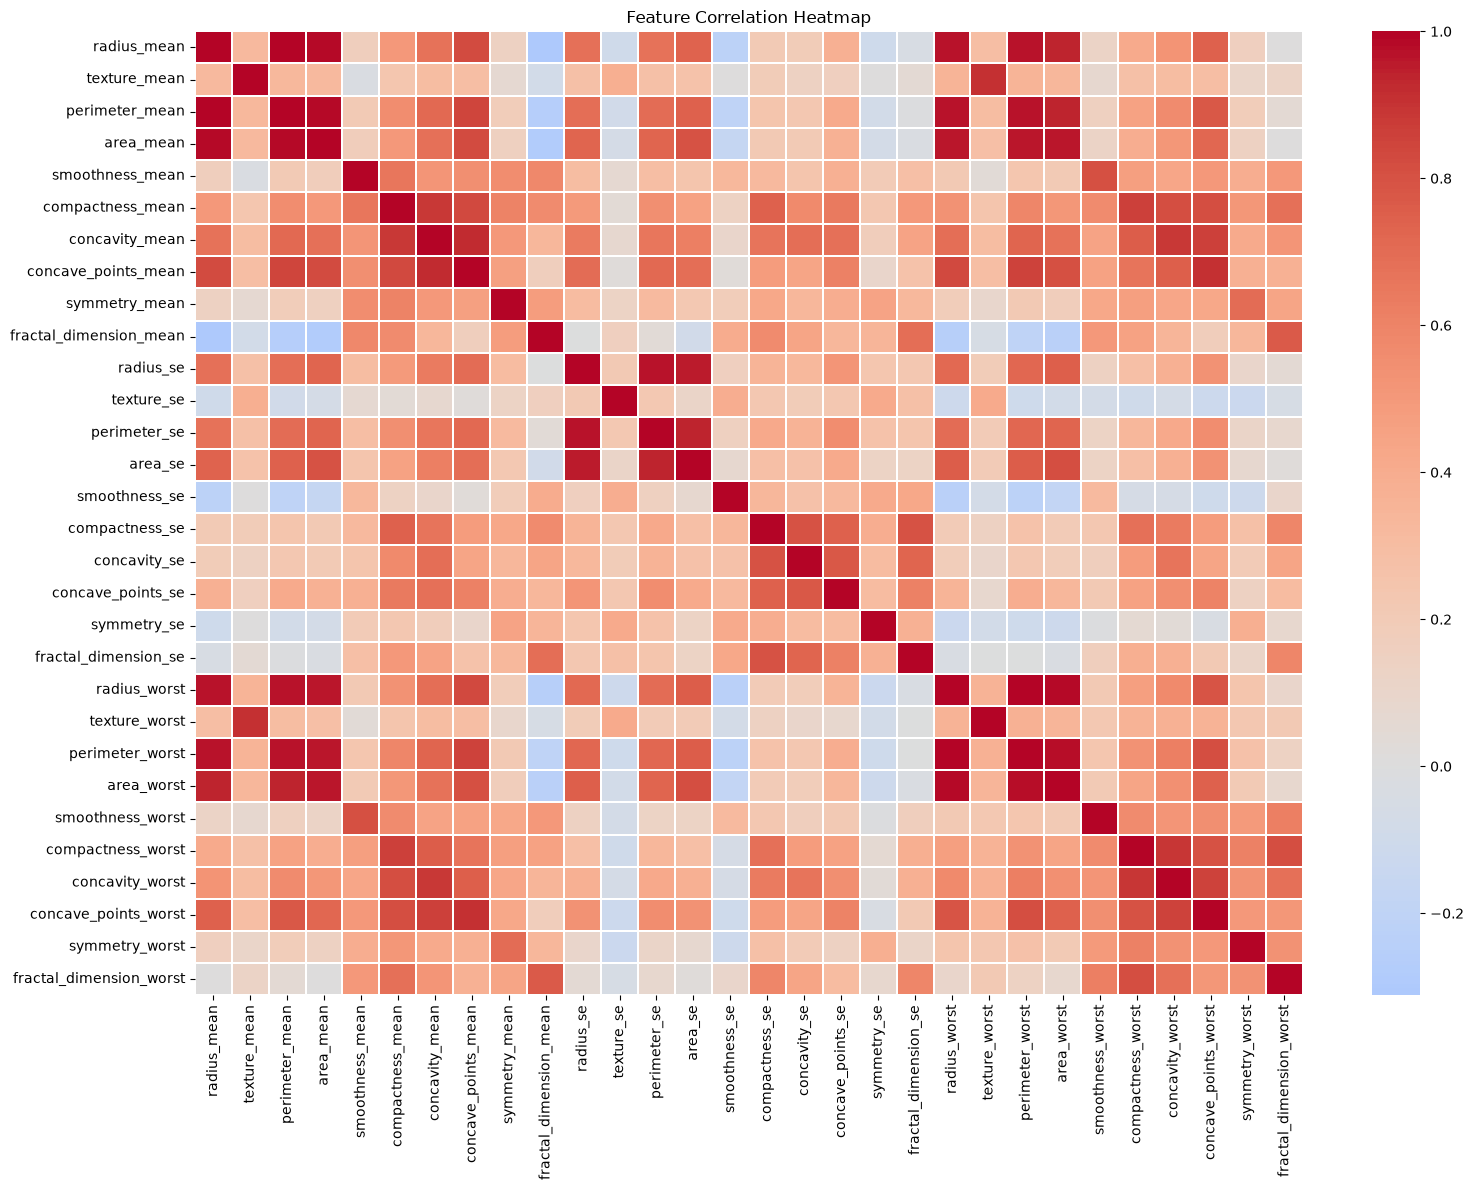

In [9]:

correlation_matrix = X.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.show()

### Observation

The correlation heatmap shows that several features are strongly correlated with each other. This indicates that some measurements contain similar information.

# Train-Test Split

Split the dataset into training and testing sets using an 80–20 ratio. Stratification is used to maintain a similar class distribution in both sets.

In [12]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

Training Features : (455, 30)
Testing Features  : (114, 30)
Training Target   : (455,)
Testing Target    : (114,)

Training Class Distribution:
Diagnosis
1    285
0    170
Name: count, dtype: int64

Testing Class Distribution:
Diagnosis
1    72
0    42
Name: count, dtype: int64


### Observation

The dataset has been divided into 80% training data and 20% testing data while maintaining the class distribution using stratified sampling.

# Decision Tree Classifier

Train a Decision Tree classifier on the training dataset to establish the initial classification performance.

In [13]:
from sklearn.tree import DecisionTreeClassifier
import time

dt_model = DecisionTreeClassifier(random_state=42)

start_time = time.time()

dt_model.fit(X_train, y_train)

dt_training_time = time.time() - start_time

y_pred_dt = dt_model.predict(X_test)

### Observation

The Decision Tree classifier was successfully trained and used to predict the classes of the test data.

# Decision Tree Performance Evaluation

Evaluate the Decision Tree using Accuracy, Precision, Recall, and F1-score.

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1 Score :", round(dt_f1, 4))
print("Training Time:", round(dt_training_time, 4), "seconds")

Accuracy : 0.9123
Precision: 0.9559
Recall   : 0.9028
F1 Score : 0.9286
Training Time: 0.0963 seconds


### Observation

The baseline Decision Tree provides the initial performance against which the tuned Decision Tree and Random Forest models can be compared.

# Decision Tree Hyperparameter Tuning

Tune the Decision Tree using criterion, maximum depth, minimum samples required for splitting, and minimum samples required at a leaf node.

In [15]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

dt_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    cv=cv,
    scoring=["accuracy", "f1"],
    refit="f1",
    return_train_score=True,
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'f1']"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to

### Observation

Grid Search evaluates different combinations of Decision Tree hyperparameters using 5-Fold Cross-Validation and selects the combination with the best F1-score.

# Best Decision Tree Parameters

Identify the hyperparameter combination that produced the best cross-validation performance.

In [16]:
print("Best Parameters:")
print(dt_grid.best_params_)

print("Best Cross-Validation F1 Score:")
print(round(dt_grid.best_score_, 4))

Best Parameters:
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best Cross-Validation F1 Score:
0.9506


### Observation

The best hyperparameter combination obtained from 5-Fold Cross-Validation is selected for the final Decision Tree model.

# Decision Tree Cross-Validation Results

Display the average cross-validation Accuracy and F1-score for the different Decision Tree hyperparameter combinations.

In [17]:
dt_results = pd.DataFrame(dt_grid.cv_results_)

dt_table = dt_results[
    [
        "param_criterion",
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf",
        "mean_test_accuracy",
        "mean_test_f1"
    ]
].copy()

dt_table.columns = [
    "Criterion",
    "Max Depth",
    "Min Samples Split",
    "Min Samples Leaf",
    "Average CV Accuracy",
    "Average CV F1"
]

dt_table = dt_table.sort_values(
    "Average CV F1",
    ascending=False
)

display(dt_table.head(15))

,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Average CV Accuracy,Average CV F1
16,gini,5,5,4,0.938462,0.950580
17,gini,5,10,4,0.938462,0.950580
44,gini,None,10,4,0.938462,0.950580
15,gini,5,2,4,0.938462,0.950580
35,gini,10,10,4,0.938462,0.950580
26,gini,7,10,4,0.938462,0.950580
50,entropy,3,10,2,0.934066,0.947973
49,entropy,3,5,2,0.934066,0.947973
45,entropy,3,2,1,0.934066,0.947973
47,entropy,3,10,1,0.934066,0.947973


### Observation

The table shows how different Decision Tree hyperparameter combinations affect the average Accuracy and F1-score obtained through 5-Fold Cross-Validation.

# Tuned Decision Tree

Use the best hyperparameters obtained from Grid Search to train the final Decision Tree and evaluate it on the test dataset.

In [18]:
best_dt = dt_grid.best_estimator_

start_time = time.time()

best_dt.fit(X_train, y_train)

dt_training_time = time.time() - start_time

y_pred_dt = best_dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

### Observation

The tuned Decision Tree is evaluated on unseen test data after selecting its optimal hyperparameters using 5-Fold Cross-Validation.

# Random Forest Classifier

Train a Random Forest classifier as an ensemble model consisting of multiple Decision Trees.

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

start_time = time.time()

rf_model.fit(X_train, y_train)

rf_training_time = time.time() - start_time

y_pred_rf = rf_model.predict(X_test)

### Observation

The Random Forest classifier combines multiple Decision Trees and produces predictions using the combined output of the trees.

# Random Forest Performance Evaluation

Evaluate the baseline Random Forest using Accuracy, Precision, Recall, and F1-score.

In [20]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("Training Time:", round(rf_training_time, 4), "seconds")

Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1 Score : 0.9655
Training Time: 0.1307 seconds


### Observation

The baseline Random Forest provides a performance reference before hyperparameter tuning.

# Random Forest Hyperparameter Tuning

Tune the Random Forest using the number of trees, maximum tree depth, number of features considered at each split, and bootstrap sampling.

In [21]:
rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 15],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=cv,
    scoring=["accuracy", "f1"],
    refit="f1",
    return_train_score=True,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True, False], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'f1']"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-f

### Observation

Grid Search evaluates different Random Forest hyperparameter combinations using 5-Fold Cross-Validation and selects the combination with the best F1-score.

# Best Random Forest Parameters

Identify the hyperparameter combination that produced the best cross-validation performance.

In [22]:
print("Best Parameters:")
print(rf_grid.best_params_)

print("Best Cross-Validation F1 Score:")
print(round(rf_grid.best_score_, 4))

Best Parameters:
{'bootstrap': False, 'max_depth': 10, 'max_features': 'log2', 'n_estimators': 200}
Best Cross-Validation F1 Score:
0.972


### Observation

The best Random Forest hyperparameter combination is selected based on the cross-validation F1-score.

# Random Forest Cross-Validation Results

Display the average cross-validation Accuracy and F1-score for the different Random Forest hyperparameter combinations.

In [23]:
rf_results = pd.DataFrame(rf_grid.cv_results_)

rf_table = rf_results[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_max_features",
        "param_bootstrap",
        "mean_test_accuracy",
        "mean_test_f1"
    ]
].copy()

rf_table.columns = [
    "N Estimators",
    "Max Depth",
    "Max Features",
    "Bootstrap",
    "Average CV Accuracy",
    "Average CV F1"
]

rf_table = rf_table.sort_values(
    "Average CV F1",
    ascending=False
)

display(rf_table.head(15))

,N Estimators,Max Depth,Max Features,Bootstrap,Average CV Accuracy,Average CV F1
41,200,10,log2,False,0.964835,0.971982
22,100,15,log2,True,0.964835,0.971801
4,100,None,log2,True,0.964835,0.971801
16,100,10,log2,True,0.964835,0.971801
47,200,15,log2,False,0.962637,0.970332
29,200,None,log2,False,0.962637,0.970332
45,50,15,log2,False,0.962637,0.970243
39,50,10,log2,False,0.962637,0.970243
27,50,None,log2,False,0.962637,0.970243
14,200,10,sqrt,True,0.962637,0.970027


### Observation

The table shows the effect of different Random Forest hyperparameter combinations on the average Accuracy and F1-score obtained using 5-Fold Cross-Validation.

# Tuned Random Forest

Use the best hyperparameters obtained from Grid Search to train the final Random Forest and evaluate it on the test dataset.

In [24]:
best_rf = rf_grid.best_estimator_

start_time = time.time()

best_rf.fit(X_train, y_train)

rf_training_time = time.time() - start_time

y_pred_rf = best_rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

### Observation

The tuned Random Forest is trained using the optimal hyperparameters and evaluated on the unseen test dataset.

# 5-Fold Cross-Validation Accuracy Comparison

Compare the accuracy of the tuned Decision Tree and Random Forest across all five folds and calculate their average accuracy.

In [25]:
dt_folds = cross_val_score(
    best_dt,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

rf_folds = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

fold_table = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Fold 1": [dt_folds[0], rf_folds[0]],
    "Fold 2": [dt_folds[1], rf_folds[1]],
    "Fold 3": [dt_folds[2], rf_folds[2]],
    "Fold 4": [dt_folds[3], rf_folds[3]],
    "Fold 5": [dt_folds[4], rf_folds[4]],
    "Average": [dt_folds.mean(), rf_folds.mean()]
})

display(fold_table.round(4))

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
0,Decision Tree,0.9451,0.9451,0.9121,0.9231,0.967,0.9385
1,Random Forest,0.9560,0.9890,0.9341,0.9670,0.978,0.9648


### Observation

The five-fold comparison shows the consistency of both models across different training and validation partitions. The average score provides an overall cross-validation performance measure.

# Final Model Performance Comparison

Compare the tuned Decision Tree and Random Forest using Accuracy, Precision, Recall, F1-score, and training time.

In [26]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy],
    "Precision": [dt_precision, rf_precision],
    "Recall": [dt_recall, rf_recall],
    "F1 Score": [dt_f1, rf_f1],
    "Training Time": [dt_training_time, rf_training_time]
})

display(comparison.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,Training Time
0,Decision Tree,0.9035,0.9420,0.9028,0.9220,0.0177
1,Random Forest,0.9561,0.9589,0.9722,0.9655,0.2169


### Observation

The final comparison shows the test-set performance of the tuned Decision Tree and Random Forest models. The model with better evaluation metrics provides stronger classification performance on the test data.

# Confusion Matrix

Visualize the confusion matrices of the tuned Decision Tree and Random Forest models to analyze correct and incorrect classifications.

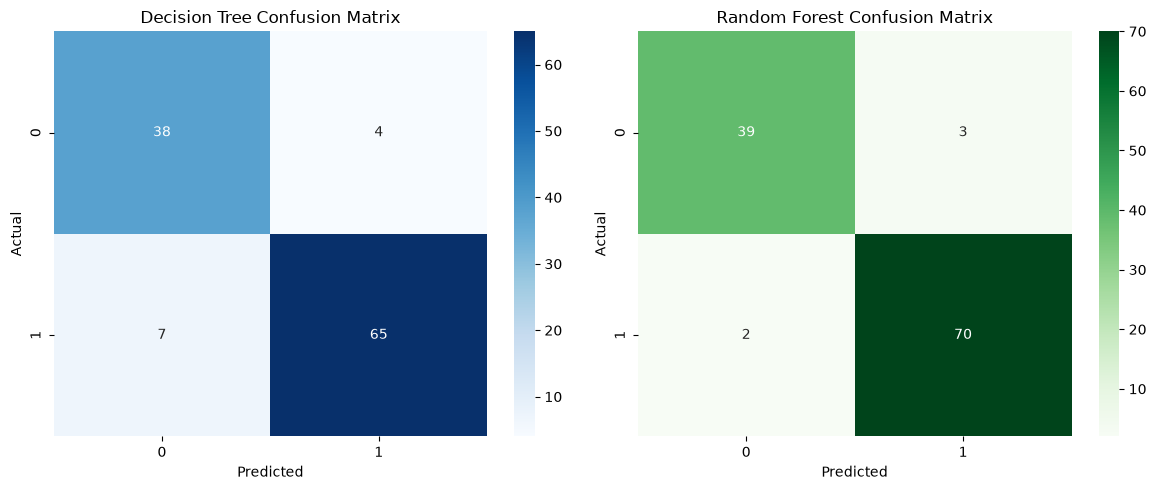

In [27]:
from sklearn.metrics import confusion_matrix

dt_cm = confusion_matrix(y_test, y_pred_dt)
rf_cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()